In [1]:
import joblib

model = joblib.load(r"../models/knn_classifier.pkl")
scaler = joblib.load(r"../models/scaler.pkl")

In [2]:
import pandas as pd

nations_df = pd.read_csv(r"../data/team_stats_processed.csv")

nations_df.head()

,team,passes,shots,average_pass_length,ppda,avg_pass_angle_deep,avg_pass_angle_mid,avg_pass_angle_final,xg_per_shot,carries_per_pass
0,Albania,392.666667,10.666667,21.152318,3.315112,-0.079853,-0.161259,1.125253,0.068238,0.820883
1,Argentina,559.666667,14.666667,20.898589,2.424673,0.003169,-0.017089,-1.030759,0.182316,0.815962
2,Austria,517.500000,12.500000,20.446254,2.142054,0.142069,0.010456,-0.161990,0.122316,0.802899
3,Belgium,551.750000,13.250000,20.983358,3.320037,-0.195753,-0.129669,0.369445,0.082606,0.855007
4,Bolivia,408.000000,5.666667,21.921076,2.087439,-0.058614,-0.425858,-0.465007,0.058136,0.772876


In [3]:
X = nations_df.drop(columns=["team"])
team = nations_df["team"]

In [ ]:
X_scaled = scaler.transform(X)

classifications = model.predict(X_scaled)



['Vertical' 'Possessional Play' 'Possessional Play' 'Vertical' 'Haramball'
 'Possessional Play' 'Vertical' 'Vertical' 'Vertical' 'Haramball'
 'Possessional Play' 'Haramball' 'Possessional Play' 'Haramball'
 'Possessional Play' 'Possessional Play' 'Possessional Play' 'Tiki-Taka'
 'Haramball' 'Possessional Play' 'Haramball' 'Possessional Play'
 'Possessional Play' 'Possessional Play' 'Vertical' 'Haramball' 'Vertical'
 'Tiki-Taka' 'Haramball' 'Haramball' 'Vertical' 'Vertical' 'Haramball'
 'Possessional Play' 'Possessional Play' 'Possessional Play' 'Vertical'
 'Haramball' 'Vertical' 'Haramball']


In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

In [9]:
import plotly.express as px

fig = px.scatter_3d(
    x=X_pca[:,0],
    y=X_pca[:,1],
    z=X_pca[:,2],
    color=classifications.astype(str),
    hover_name=team,
    title="3D Playstyle Clusters using PCA"
)

fig.show()

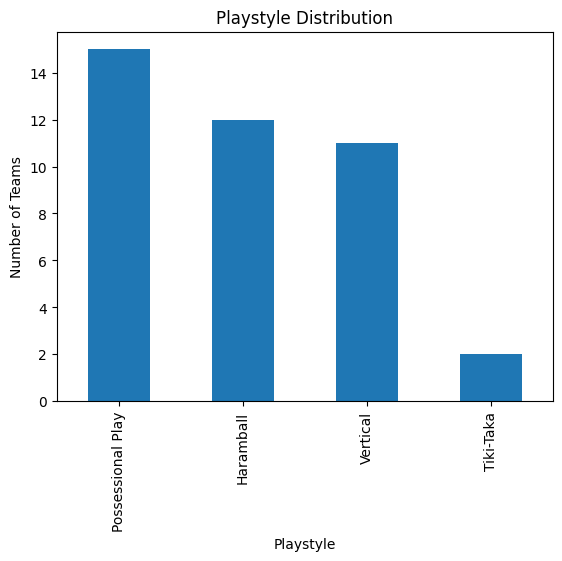

In [24]:
import matplotlib.pyplot as plt

team_predictions = pd.concat([X, pd.DataFrame(classifications), team], axis=1)

team_predictions[0].value_counts().plot(kind="bar")

plt.title("Playstyle Distribution")
plt.xlabel("Playstyle")
plt.ylabel("Number of Teams")

plt.show()

In [32]:
team_predictions.rename(columns={0: "playstyle"}, inplace=True)

In [36]:
cluster_summary = team_predictions.drop(columns=["team"]).groupby("playstyle").mean()

cluster_summary

,passes,shots,average_pass_length,ppda,avg_pass_angle_deep,avg_pass_angle_mid,avg_pass_angle_final,xg_per_shot,carries_per_pass
playstyle,,,,,,,,,
Haramball,372.263889,9.680556,23.539286,2.493955,0.006177,-0.070114,0.055725,0.098500,0.734490
Possessional Play,540.197143,13.696190,20.237334,2.695611,0.067853,-0.032422,-0.283746,0.112844,0.820344
Tiki-Taka,727.200000,19.000000,18.577286,2.509872,-0.072550,0.052250,-0.046354,0.123342,0.858838
Vertical,461.356061,12.143939,21.571338,2.614205,-0.072017,-0.075600,0.162302,0.100402,0.801086


In [44]:
team_predictions.to_csv(r"../data/national_predictions.csv", index=False)